In [1]:
import pandas as pd

df = pd.read_csv("../data/Global Weather Repository.csv")

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (166059, 10)

Column names:
['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text']


In [4]:
df.isnull().sum()

country                   0
location_name             0
latitude                  0
longitude                 0
timezone                  0
last_updated_epoch        0
last_updated              0
temperature_celsius       0
temperature_fahrenheit    0
condition_text            0
dtype: int64

In [5]:
df["last_updated"] = pd.to_datetime(df["last_updated"])

print(df["last_updated"].dtype)
print(df["last_updated"].min())
print(df["last_updated"].max())

datetime64[ns]
2024-05-16 01:45:00
2026-09-18 19:00:00


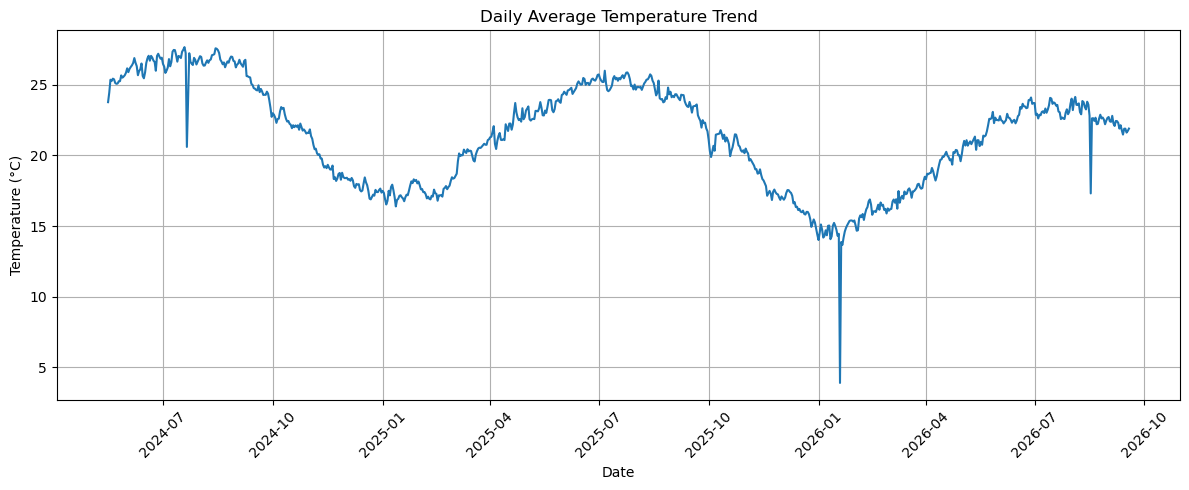

In [6]:
import matplotlib.pyplot as plt

# Calculate average temperature for each date
daily_temp = df.groupby(
    df["last_updated"].dt.date
)["temperature_celsius"].mean()

# Plot the temperature trend
plt.figure(figsize=(12, 5))
plt.plot(daily_temp.index, daily_temp.values)

plt.title("Daily Average Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
df["condition_text"].value_counts()

condition_text
Sunny                                          49019
Partly cloudy                                  42872
Patchy rain nearby                             15303
Partly Cloudy                                  11326
Overcast                                        9283
Clear                                           9248
Mist                                            6635
Light rain                                      4768
Light rain shower                               4408
Cloudy                                          2336
Fog                                             2156
Moderate or heavy rain with thunder             1211
Moderate rain                                   1136
Patchy light rain with thunder                   944
Light drizzle                                    805
Patchy light drizzle                             547
Light snow                                       525
Smoky haze                                       483
Thundery outbreaks in nearby   

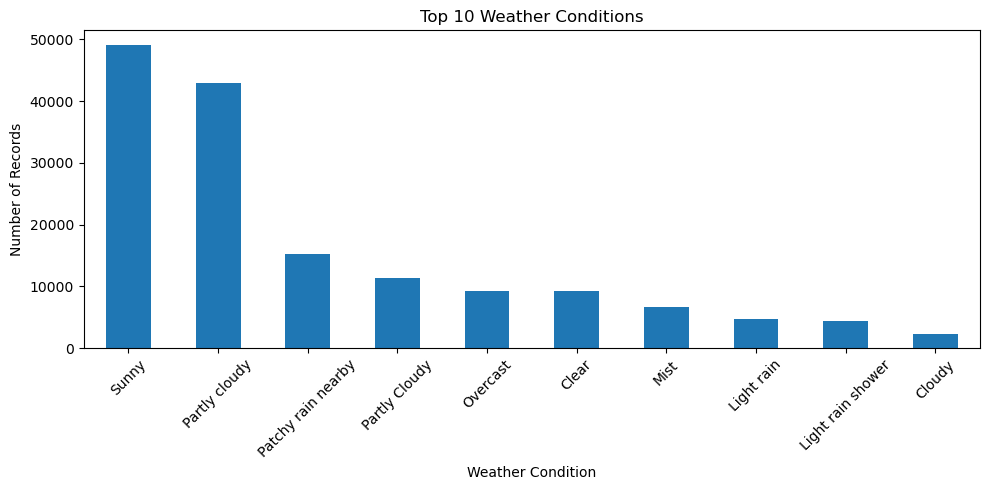

In [8]:
df["condition_text"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

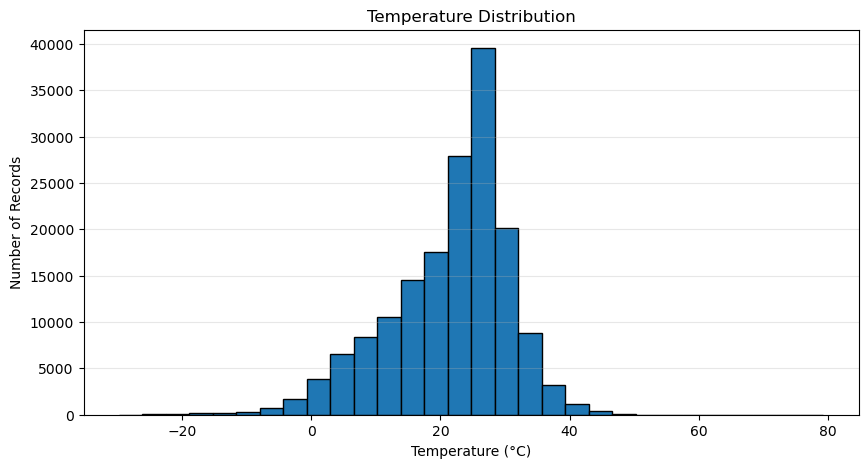

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["temperature_celsius"],
    bins=30,
    edgecolor="black"
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Number of Records")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [10]:
df["temperature_celsius"].describe()

count    166059.000000
mean         21.464849
std           9.323044
min         -29.800000
25%          16.200000
50%          23.700000
75%          27.800000
max          79.300000
Name: temperature_celsius, dtype: float64

In [11]:
print("Missing temperatures:",
      df["temperature_celsius"].isnull().sum())

print("Unique locations:",
      df["location_name"].nunique())

print("Unique countries:",
      df["country"].nunique())

Missing temperatures: 0
Unique locations: 268
Unique countries: 211


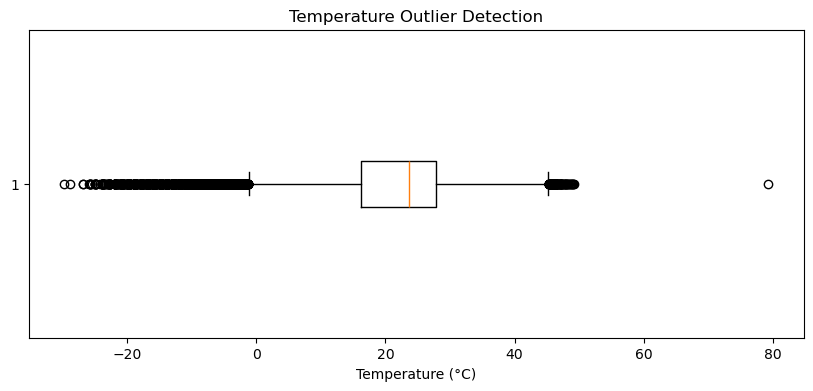

In [12]:
#Check temperature outliers

plt.figure(figsize=(10, 4))

plt.boxplot(df["temperature_celsius"], vert=False)

plt.title("Temperature Outlier Detection")
plt.xlabel("Temperature (°C)")
plt.show()

In [13]:
Q1 = df["temperature_celsius"].quantile(0.25)
Q3 = df["temperature_celsius"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = df[
    (df["temperature_celsius"] < lower_bound) |
    (df["temperature_celsius"] > upper_bound)
]

print("Number of potential outliers:", len(outliers))

Q1: 16.2
Q3: 27.8
IQR: 11.600000000000001
Lower bound: -1.2000000000000028
Upper bound: 45.2
Number of potential outliers: 3049


In [14]:
print("Lowest temperatures:")
print(
    df.nsmallest(10, "temperature_celsius")[
        ["country", "location_name", "last_updated",
         "temperature_celsius"]
    ]
)

print("\nHighest temperatures:")
print(
    df.nlargest(10, "temperature_celsius")[
        ["country", "location_name", "last_updated",
         "temperature_celsius"]
    ]
)

Lowest temperatures:
           country location_name        last_updated  temperature_celsius
118990    Mongolia   Ulaanbaatar 2026-01-18 15:00:00                -29.8
119182    Mongolia   Ulaanbaatar 2026-01-20 15:15:00                -28.9
121617     Belarus         Minsk 2026-02-02 10:00:00                -26.9
118606    Mongolia   Ulaanbaatar 2026-01-16 15:15:00                -26.8
118801    Mongolia   Ulaanbaatar 2026-01-17 15:00:00                -25.9
115680      Russia   Chi-Chi-Erh 2026-01-01 14:15:00                -25.8
118507     Belarus         Minsk 2026-01-16 10:15:00                -25.8
118774  Kazakhstan        Astana 2026-01-17 12:00:00                -25.7
119376    Mongolia   Ulaanbaatar 2026-01-21 15:00:00                -25.7
159700     Iceland         Abaer 2026-08-17 06:00:00                -25.4

Highest temperatures:
             country location_name        last_updated  temperature_celsius
137276  Fiji Islands          Suva 2026-04-24 18:30:00            

In [15]:
df.loc[
    df["temperature_celsius"] == 79.3
]

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text
137276,Fiji Islands,Suva,-18.1333,178.4167,Pacific/Fiji,1777012200,2026-04-24 18:30:00,79.3,174.7,Partly cloudy


In [16]:
print("Maximum temperature:")
print(df["temperature_celsius"].max())

print("\nRecords above 60°C:")
print(
    df[df["temperature_celsius"] > 60][
        ["country", "location_name", "last_updated",
         "temperature_celsius", "temperature_fahrenheit",
         "condition_text"]
    ]
)

Maximum temperature:
79.3

Records above 60°C:
             country location_name        last_updated  temperature_celsius  \
137276  Fiji Islands          Suva 2026-04-24 18:30:00                 79.3   

        temperature_fahrenheit condition_text  
137276                   174.7  Partly cloudy  


In [17]:
# Keep the original dataset unchanged
df_clean = df.copy()

# Flag temperatures above 60°C
suspicious = df_clean["temperature_celsius"] > 60

print("Suspicious records:", suspicious.sum())

# Exclude these records from the analysis copy
df_clean = df_clean[~suspicious].copy()

print("Original rows:", len(df))
print("Rows after filtering:", len(df_clean))

Suspicious records: 1
Original rows: 166059
Rows after filtering: 166058


In [18]:
df_clean["temperature_celsius"].describe()

count    166058.000000
mean         21.464500
std           9.321991
min         -29.800000
25%          16.200000
50%          23.700000
75%          27.800000
max          49.200000
Name: temperature_celsius, dtype: float64

In [19]:
# Filter data for Suva
suva = df_clean[
    df_clean["location_name"] == "Suva"
].copy()

# Sort observations by date
suva = suva.sort_values("last_updated")

print("Suva records:", len(suva))
print("Start date:", suva["last_updated"].min())
print("End date:", suva["last_updated"].max())

suva[["last_updated", "temperature_celsius"]].head()

Suva records: 852
Start date: 2024-05-16 20:45:00
End date: 2026-09-18 18:00:00


,last_updated,temperature_celsius
58,2024-05-16 20:45:00,26.0
253,2024-05-17 02:00:00,24.0
448,2024-05-18 04:00:00,25.0
640,2024-05-19 02:30:00,25.0
834,2024-05-20 02:00:00,26.0


In [20]:
# Calculate the time gap between consecutive Suva records
suva = suva.sort_values("last_updated")

suva["time_gap"] = suva["last_updated"].diff()

suva["time_gap"].describe()

count                          851
mean     1 days 00:06:34.477085781
std      0 days 02:17:07.786782840
min                0 days 05:15:00
25%                0 days 23:45:00
50%                1 days 00:00:00
75%                1 days 00:15:00
max                2 days 23:45:00
Name: time_gap, dtype: object

In [21]:
# Create daily average temperature for Suva
suva_daily = (
    suva.set_index("last_updated")["temperature_celsius"]
    .resample("D")
    .mean()
)

print("Daily records:", len(suva_daily))
print("Missing days:", suva_daily.isna().sum())

suva_daily.head(10)

Daily records: 856
Missing days: 5


last_updated
2024-05-16    26.0
2024-05-17    24.0
2024-05-18    25.0
2024-05-19    25.0
2024-05-20    26.0
2024-05-21    25.0
2024-05-22    25.0
2024-05-23    24.0
2024-05-24    24.0
2024-05-25    24.0
Freq: D, Name: temperature_celsius, dtype: float64

In [22]:
# Fill missing daily temperatures using nearby dates
suva_daily_filled = suva_daily.interpolate(method="time")

print("Missing values before:", suva_daily.isna().sum())
print("Missing values after:", suva_daily_filled.isna().sum())

suva_daily_filled.head(10)

Missing values before: 5
Missing values after: 0


last_updated
2024-05-16    26.0
2024-05-17    24.0
2024-05-18    25.0
2024-05-19    25.0
2024-05-20    26.0
2024-05-21    25.0
2024-05-22    25.0
2024-05-23    24.0
2024-05-24    24.0
2024-05-25    24.0
Freq: D, Name: temperature_celsius, dtype: float64

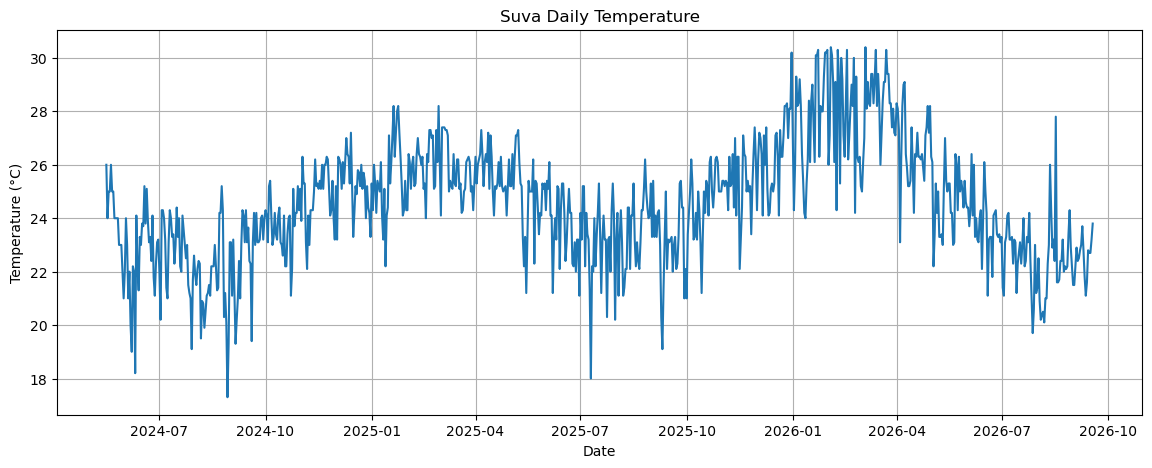

In [23]:
plt.figure(figsize=(14, 5))

plt.plot(
    suva_daily_filled.index,
    suva_daily_filled.values
)

plt.title("Suva Daily Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [24]:
# Split the daily data chronologically
split_index = int(len(suva_daily_filled) * 0.8)

train = suva_daily_filled.iloc[:split_index]
test = suva_daily_filled.iloc[split_index:]

print("Training records:", len(train))
print("Testing records:", len(test))

print("Training ends:", train.index[-1])
print("Testing starts:", test.index[0])

Training records: 684
Testing records: 172
Training ends: 2026-03-30 00:00:00
Testing starts: 2026-03-31 00:00:00


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Use the last training temperature for every test day
last_temp = train.iloc[-1]

baseline_predictions = np.full(len(test), last_temp)

# Calculate forecasting errors
mae = mean_absolute_error(test, baseline_predictions)
rmse = np.sqrt(mean_squared_error(test, baseline_predictions))

print("Last training temperature:", last_temp, "°C")
print("Baseline MAE:", round(mae, 2), "°C")
print("Baseline RMSE:", round(rmse, 2), "°C")

Last training temperature: 27.2 °C
Baseline MAE: 3.43 °C
Baseline RMSE: 3.87 °C


In [26]:
# Average temperature from the last 7 training days
last_7_days_avg = train.iloc[-7:].mean()

# Use this average for all test days
ma_predictions = np.full(len(test), last_7_days_avg)

# Calculate errors
mae_ma = mean_absolute_error(test, ma_predictions)
rmse_ma = np.sqrt(mean_squared_error(test, ma_predictions))

print("Last 7-day average:", round(last_7_days_avg, 2), "°C")
print("7-day average MAE:", round(mae_ma, 2), "°C")
print("7-day average RMSE:", round(rmse_ma, 2), "°C")

Last 7-day average: 28.3 °C
7-day average MAE: 4.44 °C
7-day average RMSE: 4.84 °C


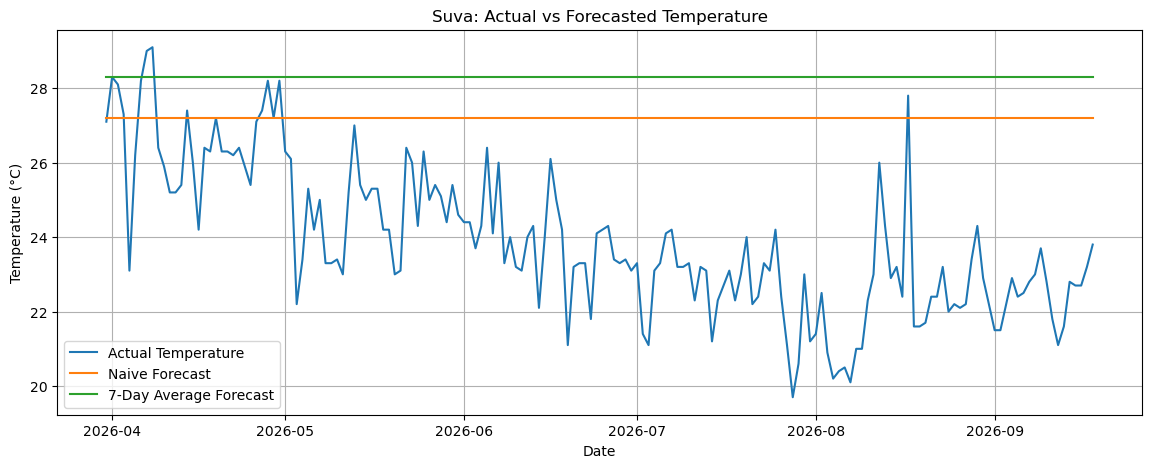

In [27]:
plt.figure(figsize=(14, 5))

plt.plot(
    test.index,
    test.values,
    label="Actual Temperature"
)

plt.plot(
    test.index,
    baseline_predictions,
    label="Naive Forecast"
)

plt.plot(
    test.index,
    ma_predictions,
    label="7-Day Average Forecast"
)

plt.title("Suva: Actual vs Forecasted Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Predict each test day using the previous day's actual temperature
rolling_predictions = pd.concat([
    train.iloc[-1:],
    test.iloc[:-1]
]).to_numpy()

# Calculate errors
mae_rolling = mean_absolute_error(test, rolling_predictions)
rmse_rolling = np.sqrt(
    mean_squared_error(test, rolling_predictions)
)

print("Rolling Forecast MAE:", round(mae_rolling, 2), "°C")
print("Rolling Forecast RMSE:", round(rmse_rolling, 2), "°C")

Rolling Forecast MAE: 0.98 °C
Rolling Forecast RMSE: 1.39 °C


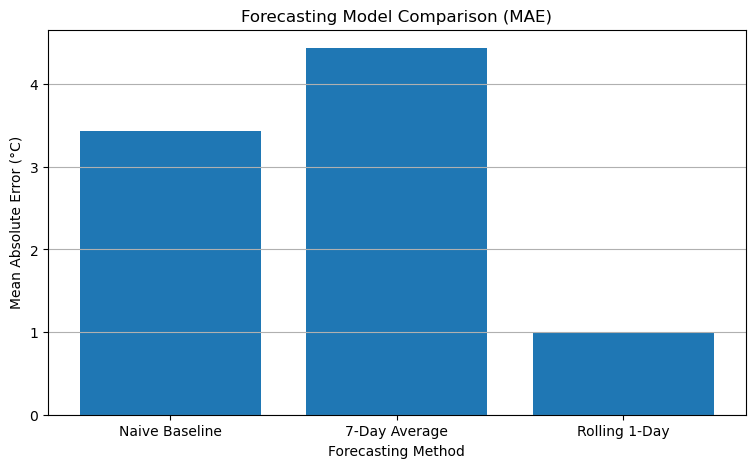

In [29]:
models = [
    "Naive Baseline",
    "7-Day Average",
    "Rolling 1-Day"
]

mae_values = [
    mae,
    mae_ma,
    mae_rolling
]

plt.figure(figsize=(9, 5))

plt.bar(models, mae_values)

plt.title("Forecasting Model Comparison (MAE)")
plt.xlabel("Forecasting Method")
plt.ylabel("Mean Absolute Error (°C)")
plt.grid(axis="y")
plt.show()

In [31]:
# Calculate quartiles
Q1 = suva_daily_filled.quantile(0.25)
Q3 = suva_daily_filled.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Find unusual temperatures
anomalies = suva_daily_filled[
    (suva_daily_filled < lower_limit) |
    (suva_daily_filled > upper_limit)
]

print("Lower limit:", round(lower_limit, 2), "°C")
print("Upper limit:", round(upper_limit, 2), "°C")
print("Number of potential anomalies:", len(anomalies))

anomalies

Lower limit: 18.6 °C
Upper limit: 30.6 °C
Number of potential anomalies: 3


last_updated
2024-06-10    18.2
2024-08-29    17.3
2025-07-10    18.0
Name: temperature_celsius, dtype: float64

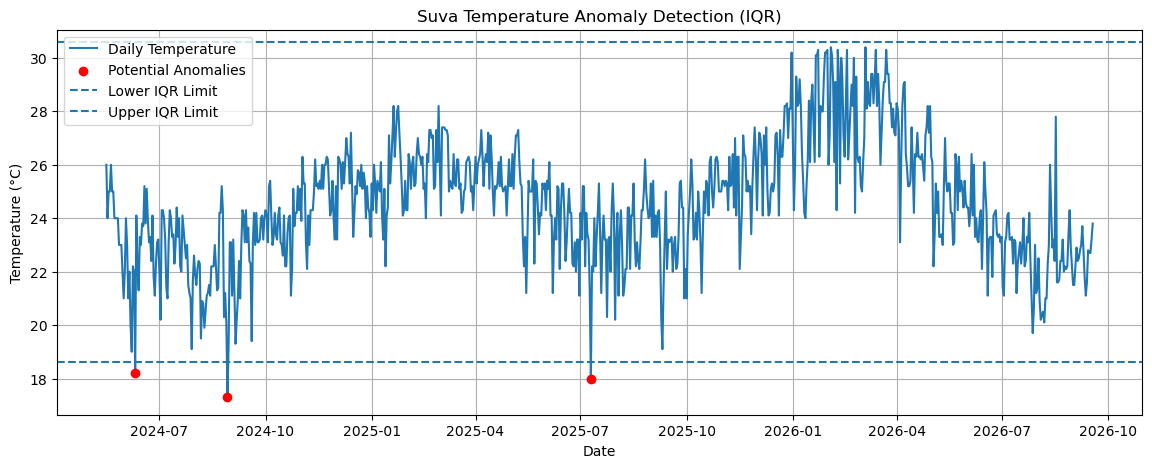

In [32]:
plt.figure(figsize=(14, 5))

# Plot all daily temperatures
plt.plot(
    suva_daily_filled.index,
    suva_daily_filled.values,
    label="Daily Temperature"
)

# Mark potential anomalies
plt.scatter(
    anomalies.index,
    anomalies.values,
    color="red",
    label="Potential Anomalies",
    zorder=5
)

plt.axhline(
    lower_limit,
    linestyle="--",
    label="Lower IQR Limit"
)

plt.axhline(
    upper_limit,
    linestyle="--",
    label="Upper IQR Limit"
)

plt.title("Suva Temperature Anomaly Detection (IQR)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

last_updated
1     26.595968
2     26.960714
3     26.982258
4     26.186667
5     24.629487
6     23.386667
7     22.773118
8     22.511828
9     22.819872
10    24.125806
11    25.101667
12    25.872581
Name: temperature_celsius, dtype: float64


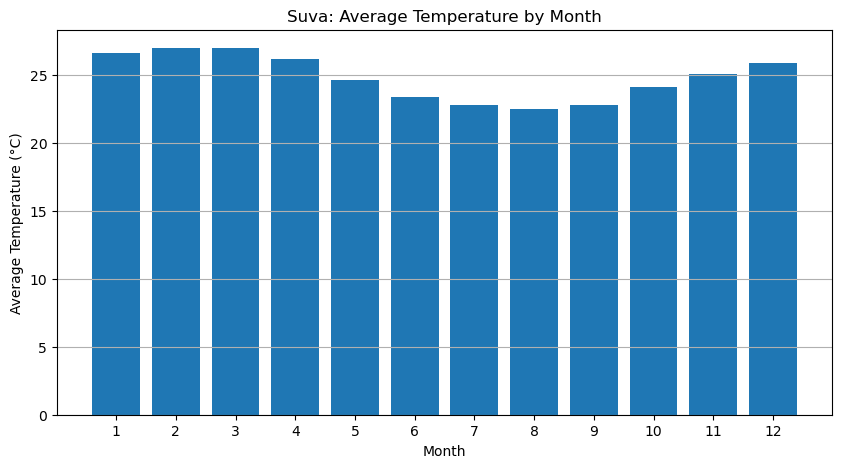

In [33]:
# Calculate average temperature for each month
monthly_temp = suva_daily_filled.groupby(
    suva_daily_filled.index.month
).mean()

# Display monthly averages
print(monthly_temp)

# Plot monthly averages
plt.figure(figsize=(10, 5))

plt.bar(monthly_temp.index, monthly_temp.values)

plt.title("Suva: Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid(axis="y")
plt.show()

In [34]:
# Combine training and test data
all_data = pd.concat([train, test])

# For each test day, average the previous 7 days
rolling_7_predictions = all_data.shift(1).rolling(
    window=7
).mean().loc[test.index]

# Remove any unavailable predictions, if present
valid = rolling_7_predictions.notna()

# Evaluate on the available test days
mae_7rolling = mean_absolute_error(
    test[valid],
    rolling_7_predictions[valid]
)

rmse_7rolling = np.sqrt(
    mean_squared_error(
        test[valid],
        rolling_7_predictions[valid]
    )
)

print("Rolling 7-day MAE:", round(mae_7rolling, 2), "°C")
print("Rolling 7-day RMSE:", round(rmse_7rolling, 2), "°C")
print("Test days evaluated:", valid.sum())

Rolling 7-day MAE: 1.03 °C
Rolling 7-day RMSE: 1.37 °C
Test days evaluated: 172


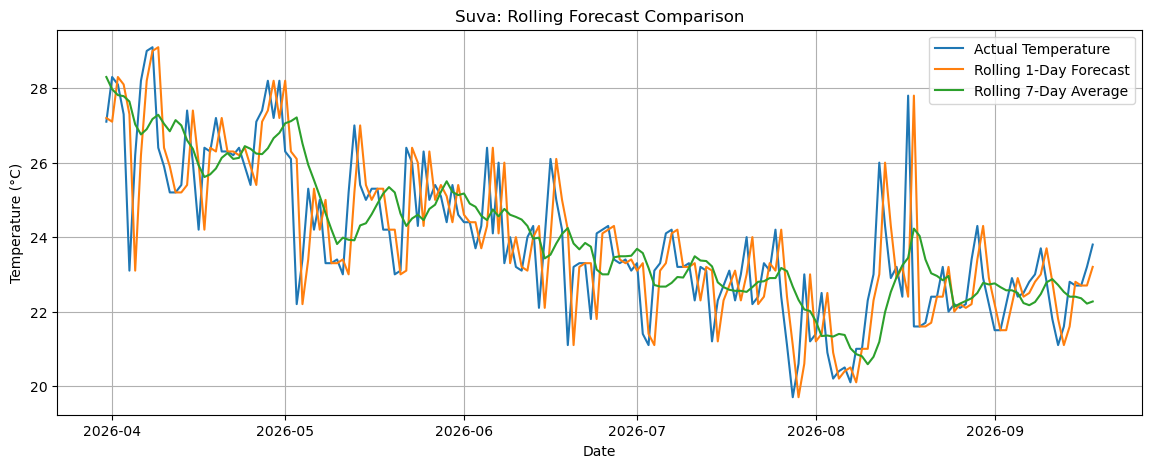

In [35]:
plt.figure(figsize=(14, 5))

plt.plot(
    test.index,
    test.values,
    label="Actual Temperature"
)

plt.plot(
    test.index,
    rolling_predictions,
    label="Rolling 1-Day Forecast"
)

plt.plot(
    test.index,
    rolling_7_predictions,
    label="Rolling 7-Day Average"
)

plt.title("Suva: Rolling Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# Calculate average temperature for each country
country_temp = (
    df_clean.groupby("country")["temperature_celsius"]
    .mean()
    .sort_values(ascending=False)
)

# Display the 10 countries with the highest averages
country_temp.head(10)

country
Saudi Arabien           45.000000
Marrocos                40.300000
Turkménistan            37.800000
Турция                  34.000000
Qatar                   32.946651
United Arab Emirates    32.553107
Cambodia                32.128169
Oman                    31.855100
Kuwait                  31.566080
Djibouti                31.524706
Name: temperature_celsius, dtype: float64

In [37]:
# Count how many records each country has
country_counts = df_clean["country"].value_counts()

# Combine average temperature and record count
country_summary = pd.DataFrame({
    "Average Temperature (°C)": country_temp,
    "Number of Records": country_counts
})

# Show the 10 countries with the highest averages
country_summary.sort_values(
    by="Average Temperature (°C)",
    ascending=False
).head(10)

,Average Temperature (°C),Number of Records
country,,
Saudi Arabien,45.000000,1
Marrocos,40.300000,1
Turkménistan,37.800000,1
Турция,34.000000,1
Qatar,32.946651,851
United Arab Emirates,32.553107,853
Cambodia,32.128169,852
Oman,31.855100,853
Kuwait,31.566080,852


In [38]:
# Keep countries with at least 100 records
reliable_countries = country_summary[
    country_summary["Number of Records"] >= 100
]

# Show the 10 highest average temperatures
top_countries = reliable_countries.sort_values(
    by="Average Temperature (°C)",
    ascending=False
).head(10)

top_countries

,Average Temperature (°C),Number of Records
country,,
Qatar,32.946651,851
United Arab Emirates,32.553107,853
Cambodia,32.128169,852
Oman,31.855100,853
Kuwait,31.566080,852
Djibouti,31.524706,850
Bangladesh,31.258451,852
Thailand,31.133724,1705
Saudi Arabia,31.127465,852


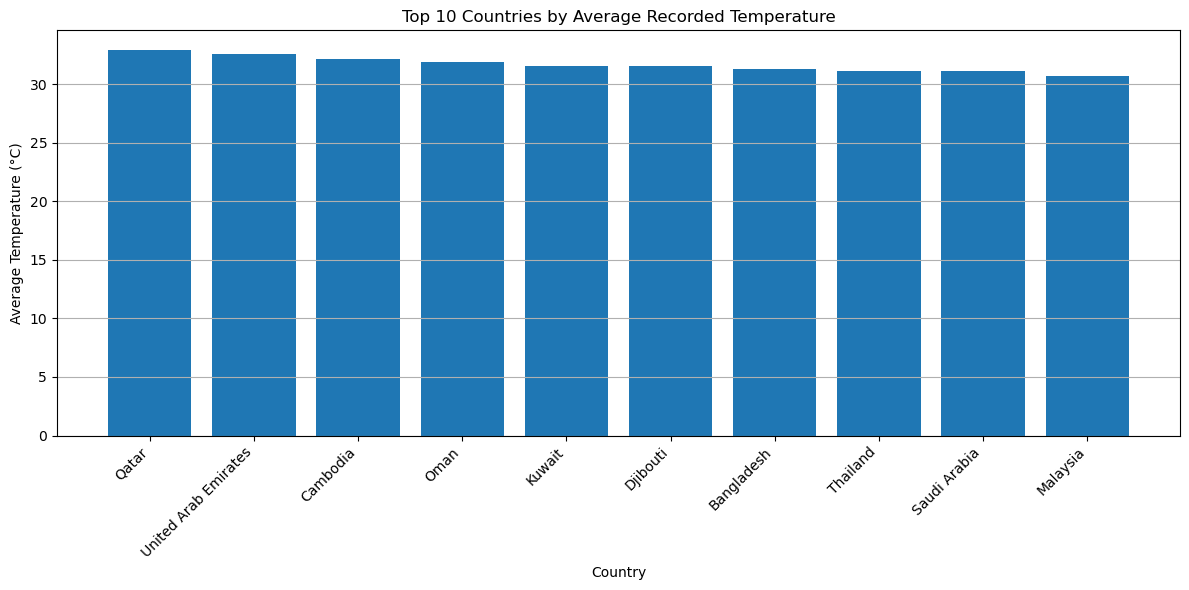

In [39]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_countries.index,
    top_countries["Average Temperature (°C)"]
)

plt.title("Top 10 Countries by Average Recorded Temperature")
plt.xlabel("Country")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [40]:
# Calculate average temperature for each weather condition
condition_temp = (
    df_clean.groupby("condition_text")["temperature_celsius"]
    .mean()
    .sort_values(ascending=False)
)

condition_temp

condition_text
Severe sandstorm                               35.998980
Sandstorm                                      34.902857
Dust storm                                     33.576471
Blowing dust                                   30.642857
Dust haze                                      27.925000
Dust                                           27.500000
Haze                                           27.174107
Patchy light rain with thunder                 26.267479
Thundery outbreaks in nearby                   25.227857
Moderate or heavy rain with thunder            25.204046
Thundery outbreaks possible                    24.923333
Moderate or heavy rain shower                  24.275683
Light rain shower                              23.947641
Torrential rain shower                         23.873077
Patchy rain nearby                             23.495230
Patchy light drizzle                           23.490494
Sunny                                          23.129303
Patchy rain poss

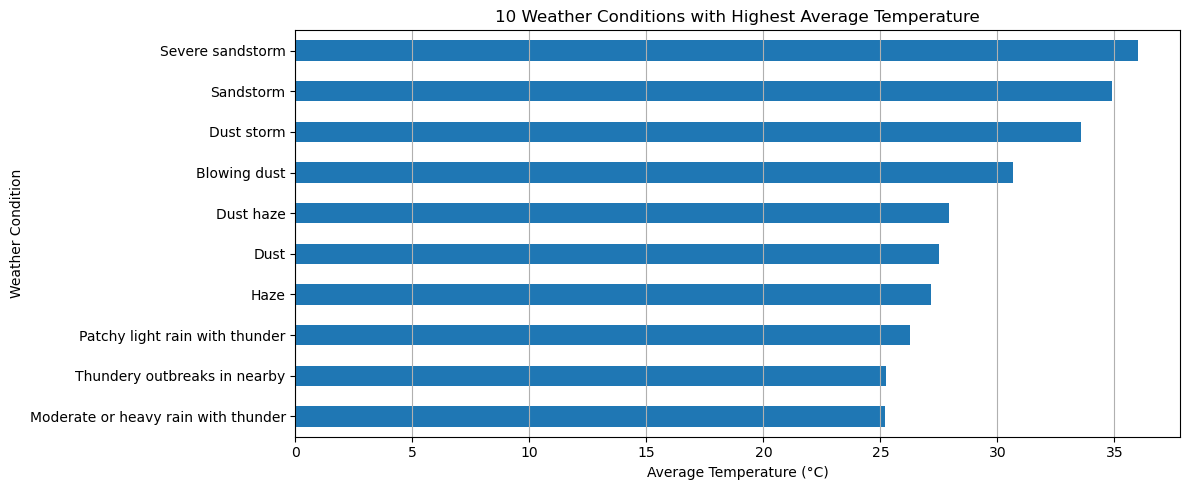

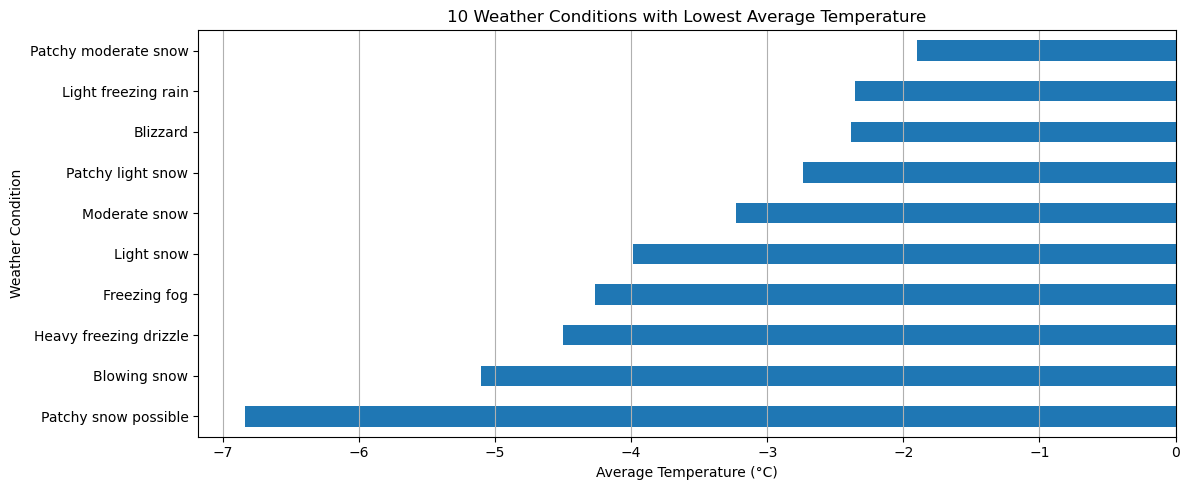

In [41]:
# Get 10 conditions with highest average temperatures
warmest_conditions = condition_temp.head(10)

# Get 10 conditions with lowest average temperatures
coolest_conditions = condition_temp.tail(10).sort_values()

# Plot warmest conditions
plt.figure(figsize=(12, 5))
warmest_conditions.sort_values().plot(kind="barh")

plt.title("10 Weather Conditions with Highest Average Temperature")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Weather Condition")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

# Plot coolest conditions
plt.figure(figsize=(12, 5))
coolest_conditions.plot(kind="barh")

plt.title("10 Weather Conditions with Lowest Average Temperature")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Weather Condition")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

In [42]:
condition_counts = df_clean["condition_text"].value_counts()

condition_counts.head(10)

condition_text
Sunny                 49019
Partly cloudy         42871
Patchy rain nearby    15303
Partly Cloudy         11326
Overcast               9283
Clear                  9248
Mist                   6635
Light rain             4768
Light rain shower      4408
Cloudy                 2336
Name: count, dtype: int64

In [43]:
# Create a standardized condition column
df_clean["condition_clean"] = (
    df_clean["condition_text"]
    .str.strip()
    .str.lower()
)

# Count conditions after standardization
condition_counts_clean = (
    df_clean["condition_clean"].value_counts()
)

condition_counts_clean.head(10)

condition_clean
partly cloudy         54197
sunny                 49019
patchy rain nearby    15303
overcast               9283
clear                  9248
mist                   6635
light rain             4768
light rain shower      4408
cloudy                 2336
fog                    2156
Name: count, dtype: int64

In [44]:
condition_avg_clean = (
    df_clean.groupby("condition_clean")["temperature_celsius"]
    .mean()
    .sort_values(ascending=False)
)

condition_avg_clean

condition_clean
severe sandstorm                               35.998980
sandstorm                                      34.902857
dust storm                                     33.576471
blowing dust                                   30.642857
dust haze                                      27.925000
dust                                           27.500000
haze                                           27.174107
patchy light rain with thunder                 26.267479
thundery outbreaks in nearby                   25.227857
moderate or heavy rain with thunder            25.204046
thundery outbreaks possible                    24.923333
moderate or heavy rain shower                  24.275683
light rain shower                              23.947641
torrential rain shower                         23.873077
patchy rain nearby                             23.495230
patchy light drizzle                           23.490494
sunny                                          23.129303
patchy rain pos

In [45]:
condition_summary = pd.DataFrame({
    "Average Temperature (°C)": condition_avg_clean,
    "Number of Records": df_clean["condition_clean"].value_counts()
})

# Sort by record count, highest first
condition_summary = condition_summary.sort_values(
    by="Number of Records",
    ascending=False
)

condition_summary.head(15)

,Average Temperature (°C),Number of Records
condition_clean,,
partly cloudy,22.092821,54197
sunny,23.129303,49019
patchy rain nearby,23.495230,15303
overcast,17.752052,9283
clear,17.820069,9248
mist,18.208335,6635
light rain,16.906586,4768
light rain shower,23.947641,4408
cloudy,19.780950,2336


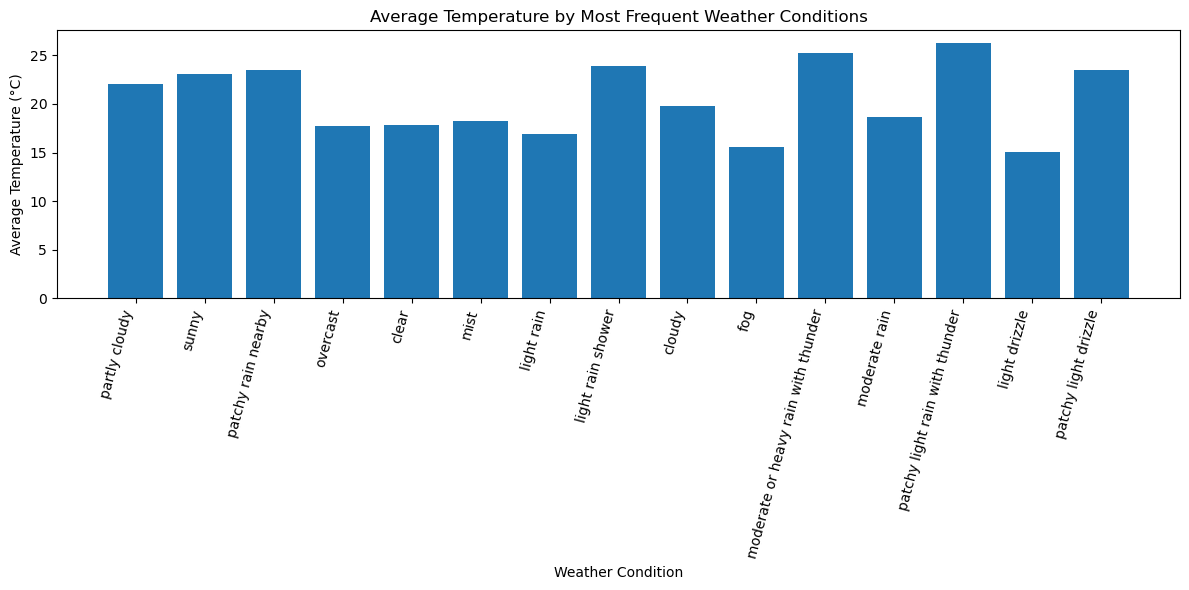

In [46]:
import matplotlib.pyplot as plt

top_conditions = condition_summary.head(15)

plt.figure(figsize=(12, 6))
plt.bar(
    top_conditions.index,
    top_conditions["Average Temperature (°C)"]
)

plt.xticks(rotation=75, ha="right")
plt.xlabel("Weather Condition")
plt.ylabel("Average Temperature (°C)")
plt.title("Average Temperature by Most Frequent Weather Conditions")
plt.tight_layout()
plt.show()

In [47]:
df.columns.tolist()

['country',
 'location_name',
 'latitude',
 'longitude',
 'timezone',
 'last_updated_epoch',
 'last_updated',
 'temperature_celsius',
 'temperature_fahrenheit',
 'condition_text']

In [48]:
location_summary = (
    df_clean.groupby("location_name")
    .agg(
        country=("country", "first"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        average_temperature=("temperature_celsius", "mean"),
        record_count=("temperature_celsius", "count")
    )
    .query("record_count >= 100")
    .sort_values("average_temperature", ascending=False)
)

location_summary.head(10)

,country,latitude,longitude,average_temperature,record_count
location_name,,,,,
Doha,Qatar,25.29,51.53,32.946651,851
Abu Dhabi,United Arab Emirates,24.47,54.37,32.553107,853
Phnom Penh,Cambodia,11.55,104.92,32.133529,850
Bangkok,Thailand,13.75,100.52,31.984155,852
Muscat,Oman,23.61,58.59,31.855100,853
Rangoon,Myanmar,16.78,96.17,31.616612,307
Kuwait City,Kuwait,29.37,47.96,31.550999,851
Djibouti,Djibouti,11.60,43.15,31.524706,850
Khartoum,Sudan,15.59,32.53,31.496005,851


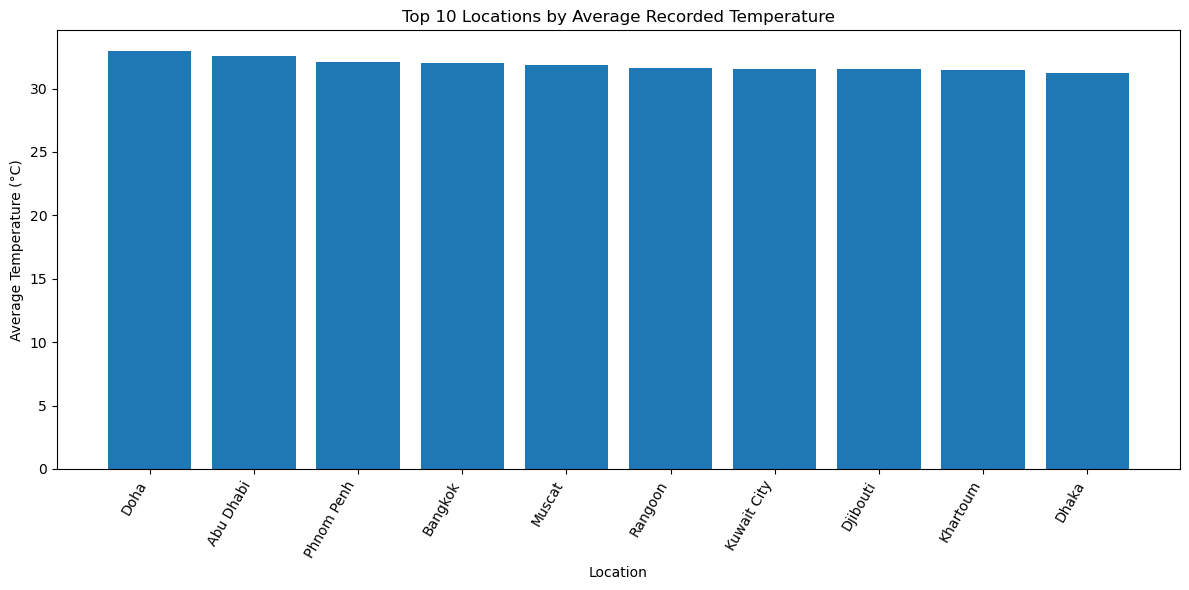

In [49]:
top_locations = location_summary.head(10)

plt.figure(figsize=(12, 6))
plt.bar(
    top_locations.index,
    top_locations["average_temperature"]
)

plt.xticks(rotation=60, ha="right")
plt.xlabel("Location")
plt.ylabel("Average Temperature (°C)")
plt.title("Top 10 Locations by Average Recorded Temperature")
plt.tight_layout()
plt.show()